In [4]:
# scripts/build_tiles_5km.py
import geopandas as gpd, shapely, json, pathlib
gdf = gpd.read_file("Countries_December_2024_Boundaries_UK_BGC_6159406507387171254.geojson").to_crs(27700)

In [5]:
# append bounds
gdf.merge(right=gdf.bounds, left_index=True, right_index=True)

,FID,CTRY24CD,CTRY24NM,CTRY24NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,minx,miny,maxx,maxy
0,1,E92000001,England,Lloegr,394883,370883,-2.07812,53.23497,0114789d-8d17-4711-9de9-8f9ac600038d,"MULTIPOLYGON (((83938.378 5430.787, 83828.48 5...",82607.348583,5424.788279,655526.263366,6.575362e+05
1,2,N92000002,Northern Ireland,Gogledd Iwerddon,86544,535337,-6.85571,54.61502,54cb8a24-8b1b-4a7f-91e4-e7938162da62,"MULTIPOLYGON (((131194.465 468431.394, 131198....",-116.192822,466189.043400,177683.145695,6.102934e+05
2,3,S92000003,Scotland,Yr Alban,277744,700060,-3.97094,56.17744,fc1644e2-d18c-441b-93b2-7bb4e970dace,"MULTIPOLYGON (((265863.926 543524.263, 265913....",5463.990783,530267.832851,470213.320047,1.220232e+06
3,4,W92000004,Wales,Cymru,263405,242881,-3.99418,52.06742,7b4dd34f-3d7e-46fe-9012-5343355d4feb,"MULTIPOLYGON (((322224.092 164693.607, 322201 ...",146615.246495,164641.110214,355216.679184,3.960120e+05


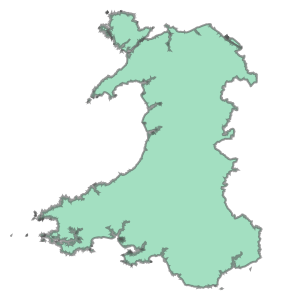

In [9]:
gdf.geometry[3]

In [ ]:
import shapely.geometry as sgeom

step = 5_000            # 5 km squares

bboxes = []

parts = []

for idx, geom in enumerate(gdf.geometry):
    xmin, ymin, xmax, ymax = geom.bounds
    for x in range(int(xmin), int(xmax), step):
        for y in range(int(ymin), int(ymax), step):
            tile = sgeom.box(x, y, x + step, y + step)
            if tile.intersects(geom):
                bbox_str   = f"{x},{y},{x+step},{y+step}"
                region_str = gdf.at[idx, "CTRY24CD"]
                parts.append(f"{bbox_str}|{region_str}")


big_string = "|||".join(parts)

pathlib.Path("tiles_5km_countries.json").write_text(json.dumps(big_string))

print(f"{len(parts)} tiles written to tiles_5km_ew.txt")

11292 tiles written to tiles_5km_ew.txt


In [15]:
parts

['82607,5424,87607,10424|E92000001',
 '82607,10424,87607,15424|E92000001',
 '82607,15424,87607,20424|E92000001',
 '87607,5424,92607,10424|E92000001',
 '87607,10424,92607,15424|E92000001',
 '87607,15424,92607,20424|E92000001',
 '92607,5424,97607,10424|E92000001',
 '92607,10424,97607,15424|E92000001',
 '92607,15424,97607,20424|E92000001',
 '127607,20424,132607,25424|E92000001',
 '132607,20424,137607,25424|E92000001',
 '132607,25424,137607,30424|E92000001',
 '132607,30424,137607,35424|E92000001',
 '132607,35424,137607,40424|E92000001',
 '137607,20424,142607,25424|E92000001',
 '137607,25424,142607,30424|E92000001',
 '137607,30424,142607,35424|E92000001',
 '137607,35424,142607,40424|E92000001',
 '142607,20424,147607,25424|E92000001',
 '142607,25424,147607,30424|E92000001',
 '142607,30424,147607,35424|E92000001',
 '142607,35424,147607,40424|E92000001',
 '142607,40424,147607,45424|E92000001',
 '147607,25424,152607,30424|E92000001',
 '147607,30424,152607,35424|E92000001',
 '147607,35424,152607